# Imports

In [105]:
import random
from tqdm import tqdm
import folium
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(
    { "figure.figsize": (17, 7) },
    style='ticks',
    palette=sns.color_palette("Set2"),
    color_codes=True,
    font_scale=5
)

plt.rcParams.update({
    "axes.labelsize": 12,  # Axes label font size
})

%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

# Stops

In [106]:
stops_df = pd.read_csv("timetables-20260312\\var\\www\\data.datalibrary.uk\\transport\\BODS-ARCHIVE\\timetables\\2026\\03\\12\\itm_yorkshire_gtfs_20260312\\stops.txt")
stops_df

,stop_id,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding,location_type,parent_station,platform_code
0,2500DCL792,landmwdg,New Line,53.690549,-2.182164,0,0,NaN,NaN
1,450012705,45012705,Whitehall Ind Est,53.778927,-1.609967,0,0,NaN,NaN
2,370035032,37035032,Bawtry Road/Brinsford Road,53.408718,-1.370039,0,0,NaN,NaN
3,450015781,45015781,Haley Hill,53.729004,-1.861444,0,0,NaN,NaN
4,2200YEA01749,22001749,Ellerton The Weres,53.850643,-0.924988,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
31992,078074769A,recgdad,Swindale Lane,54.516224,-0.959150,0,0,NaN,NaN
31993,1000DHCR3701,dbsdpgmp,The Marshes,53.347937,-1.756313,0,0,NaN,NaN
31994,3300BA0486,ntsdtjga,Ryton Fields,53.375916,-1.056434,0,0,NaN,NaN
31995,450022235,45022235,Retail Parks K,53.680696,-1.507455,0,0,NaN,NaN


In [107]:
stops_df = stops_df.loc[(stops_df["stop_lat"] < 54) & (stops_df["stop_lat"] > 53.7)].reset_index(drop=True)
stops_df = stops_df.loc[(stops_df["stop_lon"] < -1.55) & (stops_df["stop_lon"] > -1.95)].reset_index(drop=True)

In [108]:
m = folium.Map(location=[53.79, -1.75], zoom_start=11, tiles='CartoDB positron')

In [109]:
for i in range(len(stops_df)):
    stop_lat = stops_df.loc[i, "stop_lat"]
    stop_lon = stops_df.loc[i, "stop_lon"]
    stop_name = stops_df.loc[i, "stop_name"]
    
    # spot_colour = "#B55151"
    # folium.CircleMarker(
    #     location=[stop_lat, stop_lon],
    #     radius=2,
    #     popup=folium.Popup(stop_name, max_width=300),
    #     # tooltip=f"{name} | Att8: {att8} | Prg8: {prg8} | Pupils: {pup_count}",
    #     color=spot_colour,
    #     weight=1,
    #     fill=True,
    #     fill_color=spot_colour,
    #     fill_opacity=0.3
    # ).add_to(m)

# Stop Times

In [110]:
stop_times_df = pd.read_csv("timetables-20260312\\var\\www\\data.datalibrary.uk\\transport\\BODS-ARCHIVE\\timetables\\2026\\03\\12\\itm_yorkshire_gtfs_20260312\\stop_times.txt")
stop_times_df.head(1)

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:15:00,14:15:00,450029815,0,NaN,0,1,NaN,1


In [111]:
trips = pd.read_csv("timetables-20260312\\var\\www\\data.datalibrary.uk\\transport\\BODS-ARCHIVE\\timetables\\2026\\03\\12\\itm_yorkshire_gtfs_20260312\\trips.txt")
trips.head(1)

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,vehicle_journey_code
0,765,33022,VJ05426e527a583eca1e4d739323f4d5a57fe044d3,Sheffield,0,9f5f42f732ea7708b95df1b7c140fd0871355458,4e76edcf-1615-4ef8-9df0-0e3369859283,0,VJ26


In [112]:
stop_times_df = stop_times_df.merge(
    trips[["route_id", "trip_id"]],
    left_on='trip_id', 
    right_on='trip_id', 
    how='left')

In [113]:
stop_times_df

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,route_id
0,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:15:00,14:15:00,450029815,0,NaN,0,1,NaN,1,50628
1,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:18:00,14:18:00,450032483,1,NaN,0,0,NaN,0,50628
2,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:19:00,14:19:00,450032481,2,NaN,0,0,NaN,0,50628
3,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:21:00,14:21:00,450025175,3,NaN,0,0,NaN,0,50628
4,VJ00004638078b95f09f34abf1dcfb3c6c70413692,14:22:00,14:22:00,450024824,4,NaN,0,0,NaN,0,50628
...,...,...,...,...,...,...,...,...,...,...,...
7469720,VJfffeb849f05f820c704f87002906aab9e75e6182,20:16:00,20:16:00,370055029,75,NaN,0,0,NaN,0,8429
7469721,VJfffeb849f05f820c704f87002906aab9e75e6182,20:16:00,20:16:00,370055058,73,NaN,0,0,NaN,0,8429
7469722,VJfffeb849f05f820c704f87002906aab9e75e6182,20:17:00,20:17:00,370051181,77,NaN,0,0,NaN,0,8429
7469723,VJfffeb849f05f820c704f87002906aab9e75e6182,20:19:00,20:19:00,370055974,78,NaN,0,0,NaN,0,8429


In [114]:
stop_times_df["arrival_time"] = pd.to_timedelta(stop_times_df["arrival_time"])
stop_times_df["departure_time"] = pd.to_timedelta(stop_times_df["departure_time"])

In [115]:
stop_times_df = stop_times_df.sort_values(by=["trip_id", "stop_sequence"])
stop_times_df["prev_dept_time"] = stop_times_df.groupby("trip_id")["departure_time"].shift(1)
stop_times_df["travel_time"] = stop_times_df["arrival_time"] - stop_times_df["prev_dept_time"]
stop_times_df

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,route_id,prev_dept_time,travel_time
0,VJ00004638078b95f09f34abf1dcfb3c6c70413692,0 days 14:15:00,0 days 14:15:00,450029815,0,NaN,0,1,NaN,1,50628,NaT,NaT
1,VJ00004638078b95f09f34abf1dcfb3c6c70413692,0 days 14:18:00,0 days 14:18:00,450032483,1,NaN,0,0,NaN,0,50628,0 days 14:15:00,0 days 00:03:00
2,VJ00004638078b95f09f34abf1dcfb3c6c70413692,0 days 14:19:00,0 days 14:19:00,450032481,2,NaN,0,0,NaN,0,50628,0 days 14:18:00,0 days 00:01:00
3,VJ00004638078b95f09f34abf1dcfb3c6c70413692,0 days 14:21:00,0 days 14:21:00,450025175,3,NaN,0,0,NaN,0,50628,0 days 14:19:00,0 days 00:02:00
4,VJ00004638078b95f09f34abf1dcfb3c6c70413692,0 days 14:22:00,0 days 14:22:00,450024824,4,NaN,0,0,NaN,0,50628,0 days 14:21:00,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7469720,VJfffeb849f05f820c704f87002906aab9e75e6182,0 days 20:16:00,0 days 20:16:00,370055029,75,NaN,0,0,NaN,0,8429,0 days 20:16:00,0 days 00:00:00
7469719,VJfffeb849f05f820c704f87002906aab9e75e6182,0 days 20:16:00,0 days 20:16:00,370050514,76,NaN,0,0,NaN,0,8429,0 days 20:16:00,0 days 00:00:00
7469722,VJfffeb849f05f820c704f87002906aab9e75e6182,0 days 20:17:00,0 days 20:17:00,370051181,77,NaN,0,0,NaN,0,8429,0 days 20:16:00,0 days 00:01:00
7469723,VJfffeb849f05f820c704f87002906aab9e75e6182,0 days 20:19:00,0 days 20:19:00,370055974,78,NaN,0,0,NaN,0,8429,0 days 20:17:00,0 days 00:02:00


In [126]:
trip_durations = stop_times_df.groupby(["route_id", "trip_id"])["travel_time"].sum().reset_index()

In [127]:
trip_durations.loc[trip_durations["route_id"] == 30529]

,route_id,trip_id,travel_time
83799,30529,VJ0049246fe75117316af3396474d00ad1ce70b0d7,0 days 01:03:00
83800,30529,VJ007f8f6aa0156df2248e0a5bab33dbfce083e2ed,0 days 00:56:00
83801,30529,VJ00cc4af4773d5b79e633e03f9d8070d5e8cfbf52,0 days 01:03:00
83802,30529,VJ00defac3f43665ef285439692b2674c052f0cb17,0 days 00:56:00
83803,30529,VJ012b438967d3f90b8b7aac8aed4d050dca70e0b0,0 days 01:03:00
...,...,...,...
86035,30529,VJff78f7e2fabd98299a50a0ab777311b73ce44fbc,0 days 01:09:00
86036,30529,VJff7d25015ca667e98fa4f4997dd7475dece5409a,0 days 01:00:00
86037,30529,VJff851fa6ae04ed655a7abdf5e99e57f2fb49e9bf,0 days 01:00:00
86038,30529,VJffc51fbd5420aff5eefde8a13b82246796a823a0,0 days 00:55:00


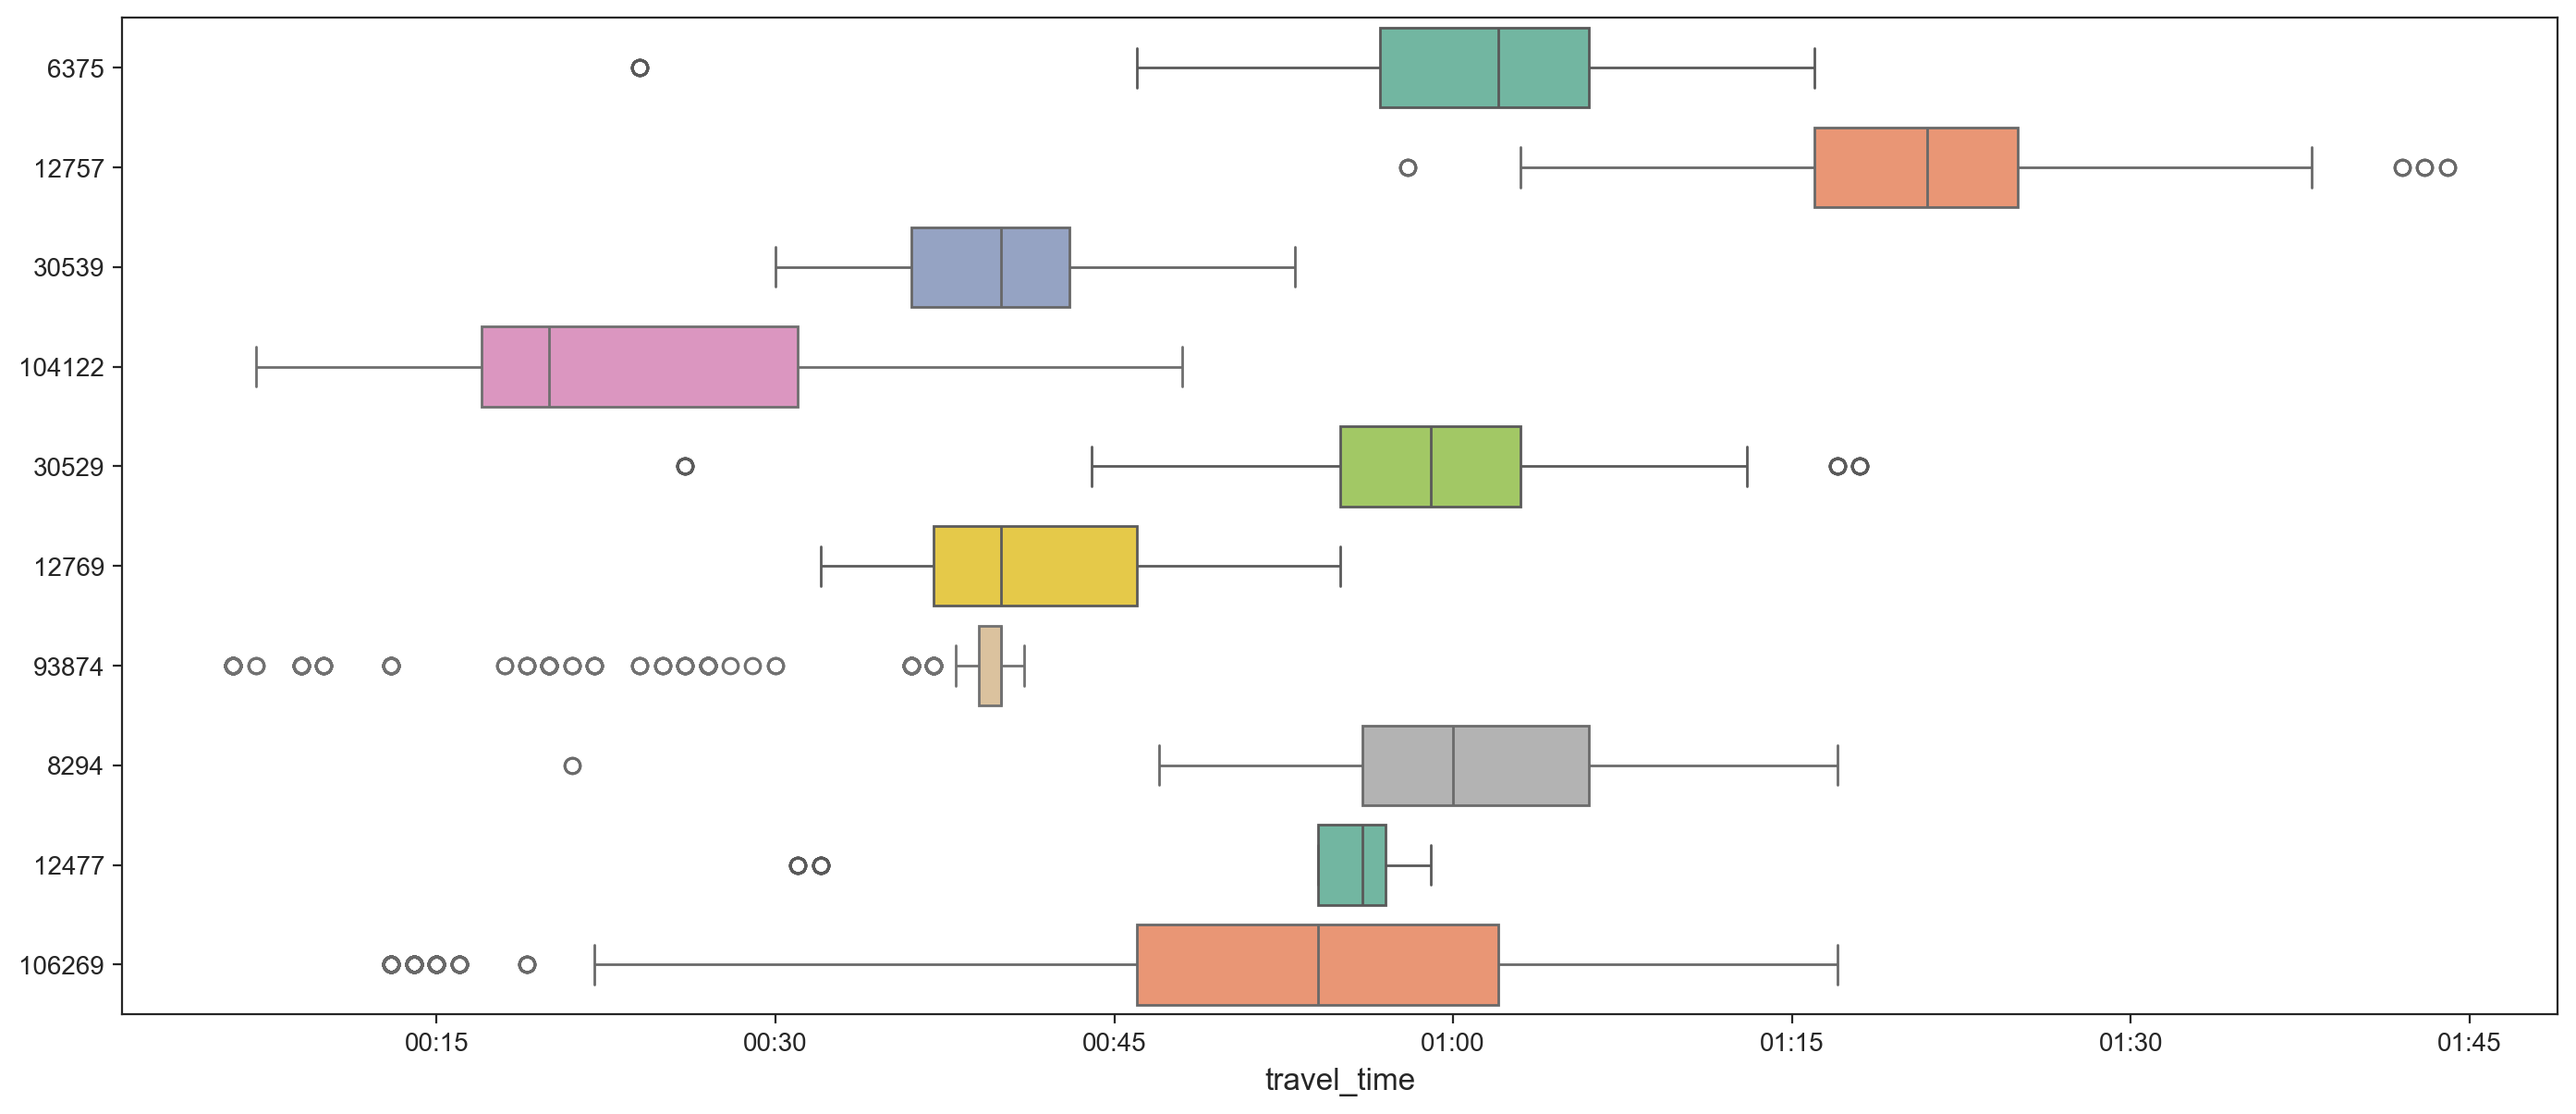

In [143]:
trip_durations = stop_times_df.groupby(["route_id", "trip_id"])["travel_time"].sum().reset_index()

for rid in trip_durations["route_id"].sample(10):
    route_trips = trip_durations.loc[trip_durations["route_id"] == rid]
    sns.boxplot(x=route_trips["travel_time"], y=rid, orient="h")

plt.xticks([0.9e12, 1.8e12, 2.7e12, 3.6e12, 4.5e12, 5.4e12, 6.3e12], ["00:15", "00:30", "00:45", "01:00", "01:15", "01:30", "01:45"])
plt.show()

For a given stop, find the trips which went through that stop
For each of those trips check which have the same route ids
For each unique route, check all the stops and times along that trip
Average all of the times between the stops to get the full bus route with timings


Other idea: Can likely get a huristic for the effects of traffic by comparing route timings between school times and quite times

In [37]:
bradford_stop_ids = list(stops_df["stop_id"].unique())
bradford_stop_ids = bradford_stop_ids[:10]
# bradford_stop_ids = ["450030028"] # Bradford Interchange Bus Station

In [38]:
plotted_routes = set()

In [39]:
for stop_id in tqdm(bradford_stop_ids):
    trips_through_stop = stop_times_df.loc[stop_times_df["stop_id"] == stop_id]

    for route_id in trips_through_stop["route_id"].unique():
        if route_id in plotted_routes: continue
        
        route_trips_df = trips_through_stop.loc[trips_through_stop["route_id"]==route_id]
        trip_id = route_trips_df.head(1)["trip_id"].item()

        stops_on_route_df = stop_times_df.loc[stop_times_df["trip_id"]==trip_id]

        spot_colour = f"#{hex(random.randrange(0, 2**24))[2:]}"# "#B55151"
        
        for stop_route_index in stops_on_route_df.index:
            stop_id = stops_on_route_df.loc[stop_route_index, "stop_id"]
            route_id = stops_on_route_df.loc[stop_route_index, "route_id"]
            arrival_time = stops_on_route_df.loc[stop_route_index, "arrival_time"]
        # for stop_id in stops_on_route_df["stop_id"]:
            stop_loc = stops_df.loc[stops_df["stop_id"] == stop_id]
            try:
                stop_lat = stop_loc["stop_lat"].item()
                stop_lon = stop_loc["stop_lon"].item()
                stop_name = stop_loc["stop_name"].item()
            except:
                continue
            folium.CircleMarker(
                location=[stop_lat, stop_lon],
                radius=3,
                popup=folium.Popup(stop_name, max_width=300),
                tooltip=f"{route_id}, time={arrival_time}",
                # tooltip=f"{name} | Att8: {att8} | Prg8: {prg8} | Pupils: {pup_count}",
                color=spot_colour,
                weight=1,
                fill=True,
                fill_color=spot_colour,
                fill_opacity=0.3
            ).add_to(m)
            
        plotted_routes.add(route_id) 

100%|██████████| 10/10 [00:30<00:00,  3.08s/it]


# Save

In [40]:
m.save("bus_stop_map.html")